# AnnotationAgent — Автоматическая разметка данных

Демонстрация всех навыков агента:
1. **auto_label** — zero-shot классификация текстов
2. **generate_spec** — генерация спецификации разметки
3. **check_quality** — оценка качества (Cohen's κ, confidence, распределение)
4. **export_to_labelstudio** — экспорт в формат LabelStudio
5. **flag_for_review** — HITL: выборка примеров с низкой уверенностью

In [1]:
import os

# Apple Silicon: prevent SIGBUS in Accelerate BLAS (must be before torch import)
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import sys
sys.path.insert(0, "..")

import pandas as pd
import json
from pathlib import Path
from agents import AnnotationAgent

## 1. Загрузка данных

In [2]:
DATA_PATH = "../../DataCollectionAgent/data/raw/sentiment_dataset.csv"
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Label distribution:\n{df['label'].value_counts()}")
df.head()

Shape: (3100, 4)
Columns: ['text', 'label', 'source', 'collected_at']
Label distribution:
label
positive    1594
negative    1506
Name: count, dtype: int64


,text,label,source,collected_at
0,. . . plays like somebody spliced random momen...,negative,hf_rotten_tomatoes,2026-03-26T15:15:45.442130+00:00
1,michael moore has perfected the art of highly ...,positive,hf_rotten_tomatoes,2026-03-26T15:15:45.442130+00:00
2,. . . too gory to be a comedy and too silly to...,negative,hf_rotten_tomatoes,2026-03-26T15:15:45.442130+00:00
3,"a graceful , contemplative film that gradually...",positive,hf_rotten_tomatoes,2026-03-26T15:15:45.442130+00:00
4,the fact that the 'best part' of the movie com...,negative,hf_rotten_tomatoes,2026-03-26T15:15:45.442130+00:00


Для демонстрации возьмём подвыборку (полная разметка занимает время из-за инференса модели).

In [3]:
SAMPLE_SIZE = 100
df_sample = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=42).reset_index(drop=True)
print(f"Sample size: {len(df_sample)}")
df_sample['label'].value_counts()

Sample size: 100


label
positive    53
negative    47
Name: count, dtype: int64

## 2. Инициализация агента

In [4]:
agent = AnnotationAgent(
    modality="text",
    confidence_threshold=0.7,
    batch_size=16,
)
print(f"Model: {agent.model_name}")
print(f"Threshold: {agent.confidence_threshold}")

Model: facebook/bart-large-mnli
Threshold: 0.7


## 3. auto_label — Автоматическая разметка

In [5]:
df_labeled = agent.auto_label(df_sample)
df_labeled[["text", "label", "predicted_label", "confidence", "needs_review"]].head(10)

2026-03-26 21:29:16,939 [INFO] Auto-detected labels from 'label': ['negative', 'positive']
2026-03-26 21:29:19,114 [INFO] Loading model facebook/bart-large-mnli (dtype=torch.float16) …
2026-03-26 21:29:19,954 [INFO] HTTP Request: HEAD https://huggingface.co/facebook/bart-large-mnli/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-26 21:29:20,050 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/bart-large-mnli/d7645e127eaf1aefc7862fd59a17a5aa8558b8ce/config.json "HTTP/1.1 200 OK"
`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

2026-03-26 21:29:20,675 [INFO] HTTP Request: GET https://huggingface.co/api/models/facebook/bart-large-mnli/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-03-26 21:29:20,881 [INFO] HTTP Request: GET https://huggingface.co/api/models/facebook/bart-large-mnli/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
2026-03-26 21:29:37,408 [INFO]   auto_label progress: 16 / 100
2026-03-26 21:29:54,763 [INFO]   auto_label progress: 32 / 100
2026-03-26 21:30:10,619 [INFO]   auto_label progress: 48 / 100
2026-03-26 21:30:24,749 [INFO]   auto_label progress: 64 / 100
2026-03-26 21:30:40,831 [INFO]   auto_label progress: 80 / 100
2026-03-26 21:30:57,927 [INFO]   auto_label progress: 96 / 100
2026-03-26 21:31:02,057 [INFO]   auto_label progress: 100 / 100
2026-03-26 21:31:02,059 [INFO] auto_label complete: 100 rows, 8 flagged for review (confidence < 0.70)


,text,label,predicted_label,confidence,needs_review
0,"what "" empire "" lacks in depth it makes up for...",positive,positive,0.8973,False
1,"a miniscule little bleep on the film radar , b...",positive,negative,0.9181,False
2,a incompetência de marcus adams como roteirist...,negative,negative,0.9915,False
3,it's a brave attempt to tap into the heartbeat...,positive,positive,0.9907,False
4,"it is amusing , and that's all it needs to be .",positive,positive,0.9766,False
5,i would have preferred a transfer down the hal...,negative,negative,0.9369,False
6,there's not a single jump-in-your-seat moment ...,negative,positive,0.5769,True
7,the truth is that the truth about charlie gets...,negative,negative,0.9914,False
8,"feels shrill , simple and soapy .",negative,negative,0.9954,False
9,the animation and backdrops are lush and inven...,negative,negative,0.8603,False


In [6]:
print(f"Predicted label distribution:\n{df_labeled['predicted_label'].value_counts()}")
print(f"\nConfidence stats:\n{df_labeled['confidence'].describe()}")
print(f"\nNeed review: {df_labeled['needs_review'].sum()} / {len(df_labeled)}")

Predicted label distribution:
predicted_label
negative    59
positive    41
Name: count, dtype: int64

Confidence stats:
count    100.000000
mean       0.902980
std        0.116379
min        0.521500
25%        0.868025
50%        0.947900
75%        0.990100
max        0.998700
Name: confidence, dtype: float64

Need review: 8 / 100


## 4. check_quality — Оценка качества разметки

In [7]:
metrics = agent.check_quality(df_labeled)
for key, value in metrics.items():
    print(f"  {key}: {value}")

2026-03-26 21:31:02,105 [INFO] Label distribution: {'negative': 59, 'positive': 41}
2026-03-26 21:31:02,106 [INFO] Confidence: mean=0.903, std=0.116, low_conf=8 (8.0%)
2026-03-26 21:31:02,109 [INFO] Cohen's κ = 0.5251, agreement = 76.00%


  label_dist: {'negative': 59, 'positive': 41}
  confidence_mean: 0.903
  confidence_std: 0.1164
  confidence_min: 0.5215
  confidence_max: 0.9987
  low_confidence_count: 8
  low_confidence_pct: 8.0
  kappa: 0.5251
  agreement: 0.76


In [9]:
!pip install matplotlib -q

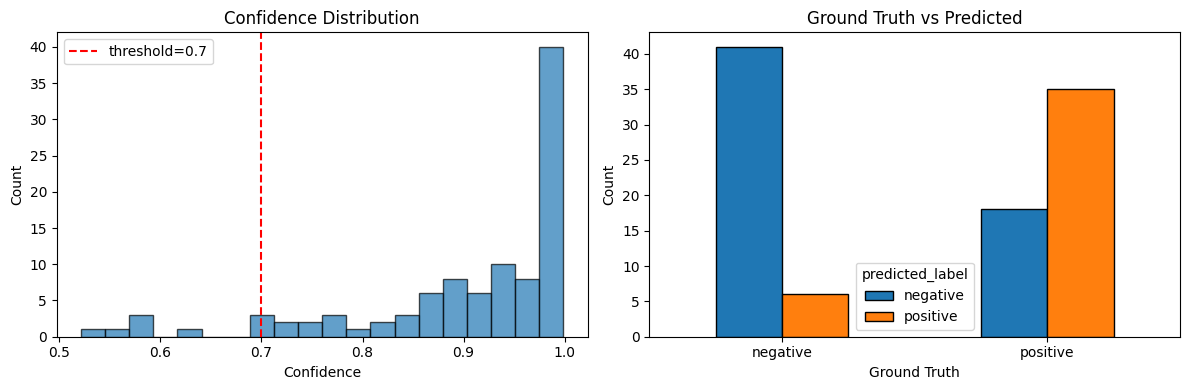


Confusion matrix:
predicted_label  negative  positive  All
label                                   
negative               41         6   47
positive               18        35   53
All                    59        41  100


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confidence distribution
axes[0].hist(df_labeled["confidence"], bins=20, edgecolor="black", alpha=0.7)
axes[0].axvline(agent.confidence_threshold, color="red", linestyle="--", label=f"threshold={agent.confidence_threshold}")
axes[0].set_title("Confidence Distribution")
axes[0].set_xlabel("Confidence")
axes[0].set_ylabel("Count")
axes[0].legend()

# Label comparison
comparison = pd.crosstab(df_labeled["label"], df_labeled["predicted_label"], margins=True)
comparison_no_margins = pd.crosstab(df_labeled["label"], df_labeled["predicted_label"])
comparison_no_margins.plot(kind="bar", ax=axes[1], edgecolor="black")
axes[1].set_title("Ground Truth vs Predicted")
axes[1].set_xlabel("Ground Truth")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print("\nConfusion matrix:")
print(comparison)

## 5. generate_spec — Спецификация разметки

In [11]:
spec_path = agent.generate_spec(
    df_labeled,
    task="sentiment_classification",
    output_path="../annotation_spec.md",
)
print(f"Spec saved → {spec_path}\n")

spec_text = Path(spec_path).read_text(encoding="utf-8")
print(spec_text)

2026-03-26 21:32:00,432 [INFO] Annotation spec saved → ../annotation_spec.md


Spec saved → ../annotation_spec.md

# Annotation Specification: sentiment_classification

## Задача

- **Тип задачи:** sentiment_classification
- **Модальность:** text
- **Количество классов:** 2
- **Объём данных:** 100 примеров

---

## Классы

### negative

**Определение:** Текст выражает отрицательное мнение, критику, неудовольствие или разочарование.

**Примеры:**

1. "a miniscule little bleep on the film radar , but one that many more people should check out"
2. "the animation and backdrops are lush and inventive , yet return to neverland never manages to take us to that elusive , lovely place where we suspend our disbelief ."
3. "beware the quirky brit-com . they can and will turn on a dime from oddly humorous to tediously sentimental ."

### positive

**Определение:** Текст выражает положительное мнение, одобрение, удовлетворение или похвалу.

**Примеры:**

1. "an infectious cultural fable with a tasty balance of family drama and frenetic comedy ."
2. "" mr . deeds " is suitable

## 6. export_to_labelstudio — Экспорт в LabelStudio

In [12]:
ls_path = agent.export_to_labelstudio(
    df_labeled,
    output_path="../labelstudio_import.json",
)
print(f"LabelStudio export → {ls_path}")

with open(ls_path, encoding="utf-8") as f:
    ls_data = json.load(f)

print(f"Total tasks: {len(ls_data)}")
print(f"\nExample task (first):\n{json.dumps(ls_data[0], indent=2, ensure_ascii=False)}")

2026-03-26 21:32:07,311 [INFO] LabelStudio export saved → ../labelstudio_import.json (100 tasks)


LabelStudio export → ../labelstudio_import.json
Total tasks: 100

Example task (first):
{
  "data": {
    "text": "what \" empire \" lacks in depth it makes up for with its heart .",
    "source": "hf_rotten_tomatoes",
    "confidence": 0.8973
  },
  "predictions": [
    {
      "model_version": "facebook/bart-large-mnli",
      "result": [
        {
          "from_name": "label",
          "to_name": "text",
          "type": "choices",
          "value": {
            "choices": [
              "positive"
            ]
          }
        }
      ],
      "score": 0.8973
    }
  ]
}


## 7. flag_for_review — HITL: Выборка для ручной разметки (Бонус)

In [13]:
review_df = agent.flag_for_review(
    df_labeled,
    output_path="../review_queue.csv",
)
print(f"Review queue: {len(review_df)} examples (confidence < {agent.confidence_threshold})")
print(f"Saved → review_queue.csv\n")

if len(review_df) > 0:
    print("Top-5 lowest confidence examples:")
    display_cols = ["text", "label", "predicted_label", "confidence"]
    display_cols = [c for c in display_cols if c in review_df.columns]
    review_df[display_cols].head()

2026-03-26 21:32:11,183 [INFO] Review queue saved → ../review_queue.csv (8 examples, confidence < 0.70)


Review queue: 8 examples (confidence < 0.7)
Saved → review_queue.csv

Top-5 lowest confidence examples:


## 8. Итоги

AnnotationAgent выполняет:
- **auto_label**: zero-shot классификация текстов через `facebook/bart-large-mnli`
- **generate_spec**: создаёт Markdown-спецификацию с определениями классов, примерами и граничными случаями
- **check_quality**: вычисляет Cohen's κ, % agreement, распределение меток, статистику confidence
- **export_to_labelstudio**: формирует JSON для импорта в LabelStudio с предразметкой
- **flag_for_review** (HITL бонус): выделяет примеры с низкой уверенностью для ручной проверки